### **Normalization**

Layer normaliztion used in the original transformer paper is used for tackling 
**internal covariate shift** in networks, where the changing distribution of the activations affects the 
learning as the updated weights couldn't adapt the changing distribution properly. The update of weights in each 
batch is for previous batch of inputs and weights and activations. But the newly updated weights creates activations 
of new distributions affecting the subsequent weights and as more layers gets added up the weights faces more issues in
adapting the new activations.

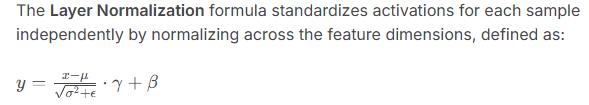

here:
 y: is the scaling factor
 B: is the shifting factor 

They are necessary to give extra expressiveness to the input after strict normaliztion to mean = 0 and standard_deviation = 1.

Layer norm exists not because networks lack the capacity to handle covariate shift — they don't. It exists because gradient descent is too simple an optimizer to reliably navigate the shifting loss landscapes that deep networks create for themselves during training. Normalization is a workaround for an optimization limitation, not a fundamental architectural necessity. We use it because it works reliably, not because it's theoretically required.

X:       (N, seq_len, d_model) <br>
mean:    (N, seq_len, 1)         ✅ <br>
std:     (N, seq_len, 1)         ✅ <br>
x_norm:  (N, seq_len, d_model)   ✅<br>
γ:       (d_model,)              ← learned scale<br>
β:       (d_model,)              ← learned shift<br>
output:  (N, seq_len, d_model)   ✅ <br>

In [1]:
import numpy as np

In [8]:
def layer_norm(X, gamma, beta, eps=1e-5):

    # step: 1 -> mean across last axis
    mean = np.mean(X, axis=-1, keepdims=True)

    # step: 2 -> standard deviation across last axis
    std = np.std(X, axis=-1, keepdims=True)

    # step: 3 -> Normalization
    y = (X - mean) / np.sqrt((std + eps)) * gamma + beta
    return y

def add_and_norm(X, sublayer_output, gamma, beta):

    output = layer_norm(X + sublayer_output, gamma, beta)
    return output

In [10]:
rng = np.random.default_rng(42)

X = rng.standard_normal((2, 6, 4))
sub_layer_output = rng.standard_normal((2, 6, 4))
gamma = np.ones(4)
beta = np.zeros(4)

output = add_and_norm(X, sub_layer_output, gamma, beta)

In [12]:
print(output.shape)

(2, 6, 4)


In [14]:
print(output.mean(axis=-1).round(5))
print(output.std(axis=-1).round(5))


[[ 0.  0.  0.  0.  0.  0.]
 [-0.  0.  0.  0. -0.  0.]]
[[0.98366 1.07115 0.88317 0.97798 0.78509 0.8691 ]
 [0.95578 1.14156 0.90913 0.90122 0.72712 0.71718]]
